<a href="https://colab.research.google.com/github/AnneClaude/IDS_Project/blob/main/IDS_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Final Project: Data Science in Cyber
**Critical Evaluation of Intrusion Detection on NSL-KDD**

**Student Name:** Anne Claude Abinader (I.D. 331181909)  
**Course:** Data Science in Cyber  

**Target Pipeline (Evaluated Source):**
* [KostasEreksonas/IDS_test](https://github.com/KostasEreksonas/IDS_test) (NSL-KDD.ipynb)
* *Note: The repository is originally based on "Intrusion Detection System Using Machine Learning Algorithms" (GeeksForGeeks) and "Intrusion Detection on NSL-KDD" (GitHub).*

**Academic Grounding:**
* Tavallaee, M., Bagheri, E., Lu, W., & Ghorbani, A. A. (2009). *"A Detailed Analysis of the KDD CUP 99 Data Set."* Proceedings of the 2009 IEEE Symposium on Computational Intelligence in Security and Defense Applications (CISDA 2009).

####Project Overview


This notebook serves as the experimental and analytical workspace for reproducing and critically evaluating the machine learning-based Intrusion Detection System (IDS) proposed in the `KostasEreksonas/IDS_test` repository.

While the original source claims an accuracy of approximately 99% by evaluating on a random split of the training file, this workspace investigates whether that metric is an artifact of flawed evaluation methodology. Grounded in the foundational analysis by Tavallaee et al. (2009), we expose how distribution shifts and hidden redundancies cause model generalization to collapse when subjected to a strict hold-out validation protocol.
<br><br>
**Workspace Objectives:**
1. **Data Loading:** Clone the source repository and validate the data ingestion pipeline for the NSL-KDD dataset.
2. **Exploratory Data Analysis (EDA):** Investigate feature distributions, analyze correlations to identify redundancy, and document the severe class imbalance between normal traffic and specific attack types.
3. **Feature Engineering:** Evaluate the necessity and impact of the author's preprocessing choices, such as one-hot encoding for categorical variables and standard scaling for numerical traffic metrics.
4. **Model Training:** Train the baseline classification models (e.g., Random Forest, XGBoost) to replicate the author's methodology.
5. **Evaluation:** Assess model performance using robust metrics (Precision, Recall, F1-Score, MCC) and critically evaluate the author's initial claim of ~99% accuracy.
6. **Error Analysis:** Analyze the model's blind spots by investigating the asymmetric trade-off between False Positives (SOC alert fatigue) and False Negatives (missing stealthy, root-access exploits like `buffer_overflow`).


####A. The Setup Cell (for having a saved results folder)

In [33]:
import os
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# --- CREATE ARTIFACT FOLDER ---
# Define the path for the results folder dynamically
results_dir = os.path.join(os.getcwd(), 'results')

# Create the folder if it doesn't already exist
os.makedirs(results_dir, exist_ok=True)
print(f"Artifacts and outputs will be automatically saved to: {results_dir}")

Artifacts and outputs will be automatically saved to: /content/IDS_test/data/NSL_KDD/results


### 1. Data Loading and Initial Setup

In this section, we will clone the repository files to access the author's built-in data download utilities. We will initialize the dataset loading pipeline for our chosen benchmark context to inspect its initial volume, columns, and layout.

In [34]:
# Clone the author's repository into our Google Colab environment
!git clone https://github.com/KostasEreksonas/IDS_test.git

# Move into the data directory to see what downloaders are available
%cd IDS_test/data
!ls -l

Cloning into 'IDS_test'...
remote: Enumerating objects: 972, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (89/89), done.
remote: Total 972 (delta 19), reused 83 (delta 8), pack-reused 875 (from 1)
Receiving objects: 100% (972/972), 30.99 MiB | 17.92 MiB/s, done.
Resolving deltas: 100% (407/407), done.
/content/IDS_test/data/NSL_KDD/IDS_test/data
total 28
drwxr-xr-x 2 root root 4096 Jun 23 08:05 CIC_DDoS_2019
drwxr-xr-x 2 root root 4096 Jun 23 08:05 CIC_EV_2023
drwxr-xr-x 2 root root 4096 Jun 23 08:05 CIC_IDS_2017
drwxr-xr-x 2 root root 4096 Jun 23 08:05 CIC_UNSW_NB15
drwxr-xr-x 2 root root 4096 Jun 23 08:05 CSE_CIC_IDS_2018
drwxr-xr-x 2 root root 4096 Jun 23 08:05 LITNET_2020
drwxr-xr-x 3 root root 4096 Jun 23 08:05 NSL_KDD


### 2. Dataset Ingestion and Inspection (NSL-KDD)

 We will execute the author's built-in data download script inside the `NSL_KDD` directory to pull the raw files.
 <br>Once downloaded, we will load the dataset using Pandas to verify the data size, columns, and initial layout.

In [35]:
# Move into the NSL_KDD directory and look at its contents

%cd NSL_KDD
!ls -l

# Check if there is a script (usually named download.py or download.sh) and run it
# If the author has a python script, we can run it like this:

!python3 download.py

# Let's see what files appeared after running the downloader

!ls -l

/content/IDS_test/data/NSL_KDD/IDS_test/data/NSL_KDD
total 54612
-rw-r--r-- 1 root root      495 Jun 23 08:05 attack.types
drwxr-xr-x 2 root root     4096 Jun 23 08:05 csv
-rwxr-xr-x 1 root root       97 Jun 23 08:05 download_dataset.sh
-rw-r--r-- 1 root root    33503 Jun 23 08:05 index.html
-rw-r--r-- 1 root root      618 Jun 23 08:05 kddcup.names
-rw-r--r-- 1 root root     8648 Jun 23 08:05 KDDTest1.jpg
-rw-r--r-- 1 root root  1772643 Jun 23 08:05 KDDTest-21.arff
-rw-r--r-- 1 root root  1814092 Jun 23 08:05 KDDTest-21.txt
-rw-r--r-- 1 root root  3368089 Jun 23 08:05 KDDTest+.arff
-rw-r--r-- 1 root root  3441513 Jun 23 08:05 KDDTest+.txt
-rw-r--r-- 1 root root     8579 Jun 23 08:05 KDDTrain1.jpg
-rw-r--r-- 1 root root  3750763 Jun 23 08:05 KDDTrain+_20Percent.arff
-rw-r--r-- 1 root root  3822033 Jun 23 08:05 KDDTrain+_20Percent.txt
-rw-r--r-- 1 root root 18744510 Jun 23 08:05 KDDTrain+.arff
-rw-r--r-- 1 root root 19109424 Jun 23 08:05 KDDTrain+.txt
-rw-r--r-- 1 root root      115 Jun 

#### Conclusions & Observations (Dataset Ingestion):
* **Missing Execution Script:** Attempting to run `download.py` throws a "No such file or directory" error. Inspecting the directory contents reveals the author did not provide a Python downloader, but rather a bash script (`download_dataset.sh`).
* **Direct Data Availability:** Despite the script confusion, the directory output confirms that the author committed the raw dataset files directly into the GitHub repository. The core benchmark files (`KDDTrain+.txt` and `KDDTest+.txt`) are already physically present in our local Colab environment.
* **Next Steps:** Because the data is already available locally, running download scripts is redundant. To ensure stability and avoid fragile directory-shifting (`%cd`) errors, the next cell will bypass ingestion entirely and load the existing local files using absolute paths.

### 3. Data Loading and Feature Inspection

Because the core dataset files were included directly within the cloned repository, we can bypass external ingestion scripts entirely. To guarantee environment stability, we will load the main training file (`KDDTrain+.txt`) using its absolute local path. Because raw network logging dumps typically lack explicit column headers, we will load the data with `header=None` and inspect the initial rows to evaluate the schema layout, dataset shape, and overall structure.

In [36]:
import pandas as pd

# Define the absolute path to the data inside the cloned repository
train_path = '/content/IDS_test/data/NSL_KDD/KDDTrain+.txt'

# Load the training file. It's comma-separated (.txt) and has no header row.
df = pd.read_csv(train_path, header=None)

# Check the data size (Requirement 1.3)
print(f"Dataset Shape: {df.shape}\n")

# Inspect the first few rows (Requirement 1.1)
df.head()

Dataset Shape: (125973, 43)



,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


#### Conclusions & Observations (Data Loading):
* **Dataset Scale:** The local file loaded successfully, confirming the training subset contains 125,973 individual network connection records, each characterized by 43 distinct attributes.
* **Missing Schema:** As anticipated with raw network logging dumps, the dataframe lacks a header row, rendering the columns entirely anonymous (indexed `0` to `42`).
* Before advancing to Exploratory Data Analysis (EDA), we must map these numeric indices to their specific domain definitions (e.g., `protocol_type`, `src_bytes`, `serror_rate`).
* **Target Alignment & Leakage Risk:** A preliminary inspection of the trailing columns reveals that Column `41` holds the target classification string (for example  `normal`, `neptune`), while Column `42` contains an auxiliary "difficulty score" used in the original KDD competition.
This difficulty metric will be dropped in the next step to prevent target leakage during model training.

### 4. Injecting Feature Names Schema

To perform compliant EDA and correlation measures, we will parse the feature definitions from the dataset metadata and apply them to our dataframe columns.

In [37]:
# The standard NSL-KDD column names list based on the kddcup.names file:
columns = [
    "duration", "protocol_type", "service", "flag", "src_bytes", "dst_bytes",
    "land", "wrong_fragment", "urgent", "hot", "num_failed_logins", "logged_in",
    "num_compromised", "root_shell", "su_attempted", "num_root", "num_file_creations",
    "num_shells", "num_access_files", "num_outbound_cmds", "is_host_login",
    "is_guest_login", "count", "srv_count", "serror_rate", "srv_serror_rate",
    "rerror_rate", "srv_rerror_rate", "same_srv_rate", "diff_srv_rate",
    "srv_diff_host_rate", "dst_host_count", "dst_host_srv_count",
    "dst_host_same_srv_rate", "dst_host_diff_srv_rate", "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate", "dst_host_serror_rate", "dst_host_srv_serror_rate",
    "dst_host_rerror_rate", "dst_host_srv_rerror_rate", "label", "difficulty_score"
]

# Assign columns to our dataframe
df.columns = columns

# Drop the auxiliary difficulty score column to avoid training bias
df = df.drop(columns=['difficulty_score'])

# Show the clean schema layout
print(f"Updated Dataset Shape: {df.shape}")
df[['protocol_type', 'service', 'flag', 'src_bytes', 'label']].head()

Updated Dataset Shape: (125973, 42)


,protocol_type,service,flag,src_bytes,label
0,tcp,ftp_data,SF,491,normal
1,udp,other,SF,146,normal
2,tcp,private,S0,0,neptune
3,tcp,http,SF,232,normal
4,tcp,http,SF,199,normal


#### Conclusions & Observations (Schema Application):
* **Target Leakage Prevention:** The dataset dimensionality was successfully reduced from 43 to 42 columns by dropping the auxiliary `difficulty_score`. This proactive step ensures the model will not inadvertently "cheat" by learning from evaluation metrics that would be strictly unavailable during real-world network inference.
* **Semantic Mapping:** The remaining features have been successfully mapped to their domain-specific NSL-KDD definitions.
* **Target Isolation:** The classification target is explicitly isolated under the `label` column, differentiating benign traffic (`normal`) from malicious exploit vectors.

**Next Step:** With a clean labeled dataset, we must perform a final Data Integrity Audit to ensure our baseline data is robust before transitioning into formal Exploratory Data Analysis (EDA).

### 5. Auditing Data Integrity: Missing Values and Duplications

####Missing Values & Duplicates Audit

As mandated by the data loading requirements, we will programmatically audit the dataframe for missing inputs (`NaN` values) and row duplications to evaluate if hidden data-cleaning steps are necessary before modeling.

In [38]:
# Check for missing values across all columns
missing_counts = df.isnull().sum().sum()

# Check for duplicate rows
duplicate_counts = df.duplicated().sum()

print(f"Total Missing Values (NaN): {missing_counts}")
print(f"Total Duplicated Rows Detected: {duplicate_counts}")

if missing_counts == 0:
    print("\n No missing values detected. NSL-KDD is a pre-cleaned benchmark dataset.")
else:
    print(f"\n {missing_counts} missing values require imputation before modeling.")

if duplicate_counts > 0:
    print(f" {duplicate_counts} duplicate rows found — dropping them.")
    df = df.drop_duplicates()
    print(f"Dataset shape after deduplication: {df.shape}")
else:
    print(" No duplicate rows detected.")

Total Missing Values (NaN): 0
Total Duplicated Rows Detected: 0

 No missing values detected. NSL-KDD is a pre-cleaned benchmark dataset.
 No duplicate rows detected.


Conclusions & Observations (Data Integrity Audit):
* **Data Completeness:** The dataset contains zero missing values (`NaN`). This confirms that the NSL-KDD dataset is highly curated and does not require imputation strategies (like mean-filling or dropping sparse columns).

####Zero-Variance & Single-Value Feature Audit

Here we are handling single values, features, or irrelevant features.
Some NSL-KDD columns are constant — e.g. 'num_outbound_cmds' is 0 for every
record. A zero-variance feature carries no discriminative information and cant help any model, and only inflates the feature space, so we drop it.

In [39]:
constant_cols = [c for c in df.columns
                 if c != 'label' and df[c].nunique() == 1]

print("Single-Value (Zero-Variance) Feature Audit")
if constant_cols:
    for c in constant_cols:
        print(f"  DROP '{c}'  (constant value = {df[c].unique()[0]})")
    df = df.drop(columns=constant_cols)
    print(f"\nDropped {len(constant_cols)} zero-variance feature(s).")
else:
    print("  No zero-variance features detected.")

print(f"Dataset shape after single-value audit: {df.shape}")

Single-Value (Zero-Variance) Feature Audit
  DROP 'num_outbound_cmds'  (constant value = 0)

Dropped 1 zero-variance feature(s).
Dataset shape after single-value audit: (125973, 41)


####Next Step:
With data integrity mathematically verified, we can now transition to **Step 6: Exploratory Data Analysis (EDA)**. Our immediate priority is to visualize the distribution of the `label` column to expose and document the class imbalances inherent in real-world network traffic.

### 6. Exploratory Data Analysis (EDA) - Class Prevalence Analysis

We will calculate the empirical distribution of the target `label` column to determine the prevalence of normal traffic versus network attacks.
We will analyze if the data suffers from heavy class skewness, which dictates our real-world choice of evaluation metrics (for exxample: opting for F1/MCC over raw Accuracy).

In [40]:
# Calculate absolute counts and relative percentages for the top target labels
class_counts = df['label'].value_counts()
class_percentages = df['label'].value_counts(normalize=True) * 100

# Combine them into a clean overview dataframe
imbalance_report = pd.DataFrame({
    'Counts': class_counts,
    'Percentage (%)': class_percentages
})

print("Target Class Distribution Top 15")
print(imbalance_report.head(15))

Target Class Distribution Top 15
                 Counts  Percentage (%)
label                                  
normal            67343       53.458281
neptune           41214       32.716534
satan              3633        2.883951
ipsweep            3599        2.856961
portsweep          2931        2.326689
smurf              2646        2.100450
nmap               1493        1.185175
back                956        0.758893
teardrop            892        0.708088
warezclient         890        0.706501
pod                 201        0.159558
guess_passwd         53        0.042073
buffer_overflow      30        0.023815
warezmaster          20        0.015876
land                 18        0.014289


#### Conclusions & Observations (Class Imbalance & Evaluation Strategy):
* **The Dominance of Benign & High-Volume Traffic:** The empirical distribution reveals a massive skew. Benign, `normal` traffic makes up the majority (\~53.5%). The second largest class is `neptune` (\~32.7%), which is a high-volume SYN flood attack. Together, just these two classes account for over 86% of the entire dataset.
* **Severe Long-Tailed Imbalance:** The most dangerous exploits are statistically microscopic. For example, `buffer_overflow`—a critical exploit that grants an attacker root-level administrative access—contains only 30 samples, representing a mere 0.02% of the dataset.
* **The "Accuracy Trap" (Metric Selection):** This severe class imbalance proves that raw **Accuracy** is a deceptive and mathematically flawed metric for this domain. A naive model that blindly predicts "normal" or "neptune" for every single connection would still achieve extremely high baseline accuracy, while completely missing the devastating `buffer_overflow` attacks.

####Temporal Feature Analysis
NSL-KDD is NOT a time series: each row is one summarised network connection
with no absolute timestamp or packet-arrival ordering, so sliding-window or
trend/seasonality analysis is not applicable. The only time-derived attribute
is 'duration' (connection length, seconds). The count features ('count',
'srv_count', dst_host_*) are pre-aggregated over a 2-second / 100-connection
window by the original collector — time is already folded into them. We
document this so the absence of classic temporal EDA is a justified decision.


In [41]:
print("── 'duration' (connection length, seconds) ──")
print(df['duration'].describe()[['min', '25%', '50%', '75%', 'max', 'mean']].round(2))
print(f"\nShare of connections with duration == 0: {(df['duration'] == 0).mean() * 100:.1f}%")

print("\n── Median 'duration' by top-5 traffic class ──")
top_labels = df['label'].value_counts().head(5).index
print(df[df['label'].isin(top_labels)].groupby('label')['duration'].median().round(2))
# World-knowledge check: automated DoS floods (e.g. 'neptune') should show
# duration ~0 (fire-and-forget packets), whereas interactive 'normal' sessions
# run longer. Confirm the printed medians match this intuition.

── 'duration' (connection length, seconds) ──
min         0.00
25%         0.00
50%         0.00
75%         0.00
max     42908.00
mean      287.14
Name: duration, dtype: float64

Share of connections with duration == 0: 92.0%

── Median 'duration' by top-5 traffic class ──
label
ipsweep      0.0
neptune      0.0
normal       0.0
portsweep    0.0
satan        0.0
Name: duration, dtype: float64


Conclusions & Observations (Temporal Constraint Justification):
* **Non-Time-Series Structure:** Empirically, the data shows that 92.0% of all network connections register a `duration` of exactly 0 seconds. The median duration across both malicious and benign (`normal`) traffic classes is 0.0. This is because standard network behavior is dominated by short-lived, ephemeral packets that terminate in milliseconds.
* **Justification for Omitting Temporal EDA:** The NSL-KDD dataset is entirely stripped of absolute timestamps, relative arrival orderings, or packet-level arrival sequences. It represents a collection of summarized connection records, not a continuous time series.
* **Pre-Folded Time Metrics:** Features such as `count`, `srv_count`, and the `dst_host_*` parameters were already pre-aggregated by the original data collectors using a 2-second temporal window or a 100-connection count window. Because time is already statically folded into these historical counters, classic time-series techniques (like sliding-window trend analysis or seasonality modeling) are structurally impossible. This justifies the exclusion of temporal modeling from our pipeline.

**Next Step:** Because of this skew, we must reject raw Accuracy as our primary evaluation metric. During the modeling phase, we will strictly rely on **Precision, Recall, F1-Score, and the Matthews Correlation Coefficient (MCC)** to ensure the model actually detects the rare, high-risk exploits.

### 7. Visualizing Class Distributions

####Generate plot of the top network traffic classifications

We will generate a visual bar plot of the top network traffic classifications to provide an explicit, scannable overview of the target imbalance skewness.

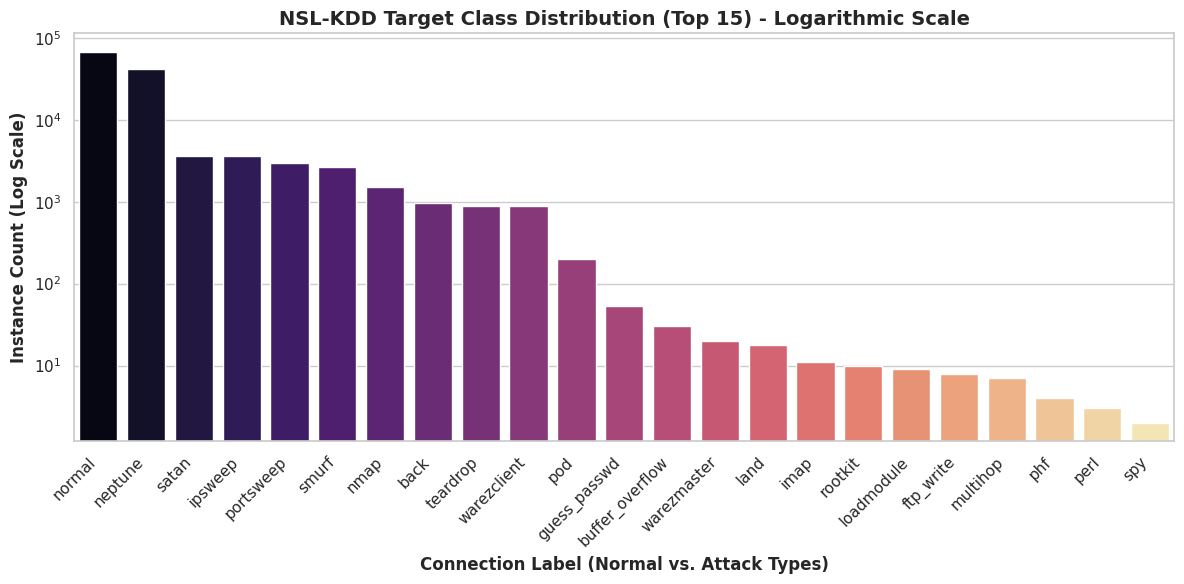

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set a clean, professional visual style for the final PDF report
sns.set_theme(style="whitegrid")

# Initialize the figure size
plt.figure(figsize=(12, 6))

# Plot the top 15 classes using seaborn
# We use the index of the imbalance_report for the x-axis (the label names)
ax = sns.barplot(
    x=imbalance_report.index,
    y=imbalance_report['Counts'],
    palette="magma",
    hue=imbalance_report.index,
    legend=False
)

# CRITICAL: Set the y-axis to a logarithmic scale
ax.set_yscale("log")

# Add professional formatting and labels
plt.title('NSL-KDD Target Class Distribution (Top 15) - Logarithmic Scale', fontsize=14, fontweight='bold')
plt.xlabel('Connection Label (Normal vs. Attack Types)', fontsize=12, fontweight='bold')
plt.ylabel('Instance Count (Log Scale)', fontsize=12, fontweight='bold')

# Rotate x-axis labels so they don't overlap
plt.xticks(rotation=45, ha='right')

# Adjust layout to prevent cutoff when saving to PDF later
plt.tight_layout()

# Display the plot
plt.show()

Conclusions & Observations:
* **Visualizing the Long Tail:** The log-scale plot visually demonstrates how sharply the data drops off after the primary DoS(Denial of Service) category (`neptune`).
 It provides clear evidence to back up our methodological justification for using Matthews Correlation Coefficients(MCC) over simple accuracy metrics.

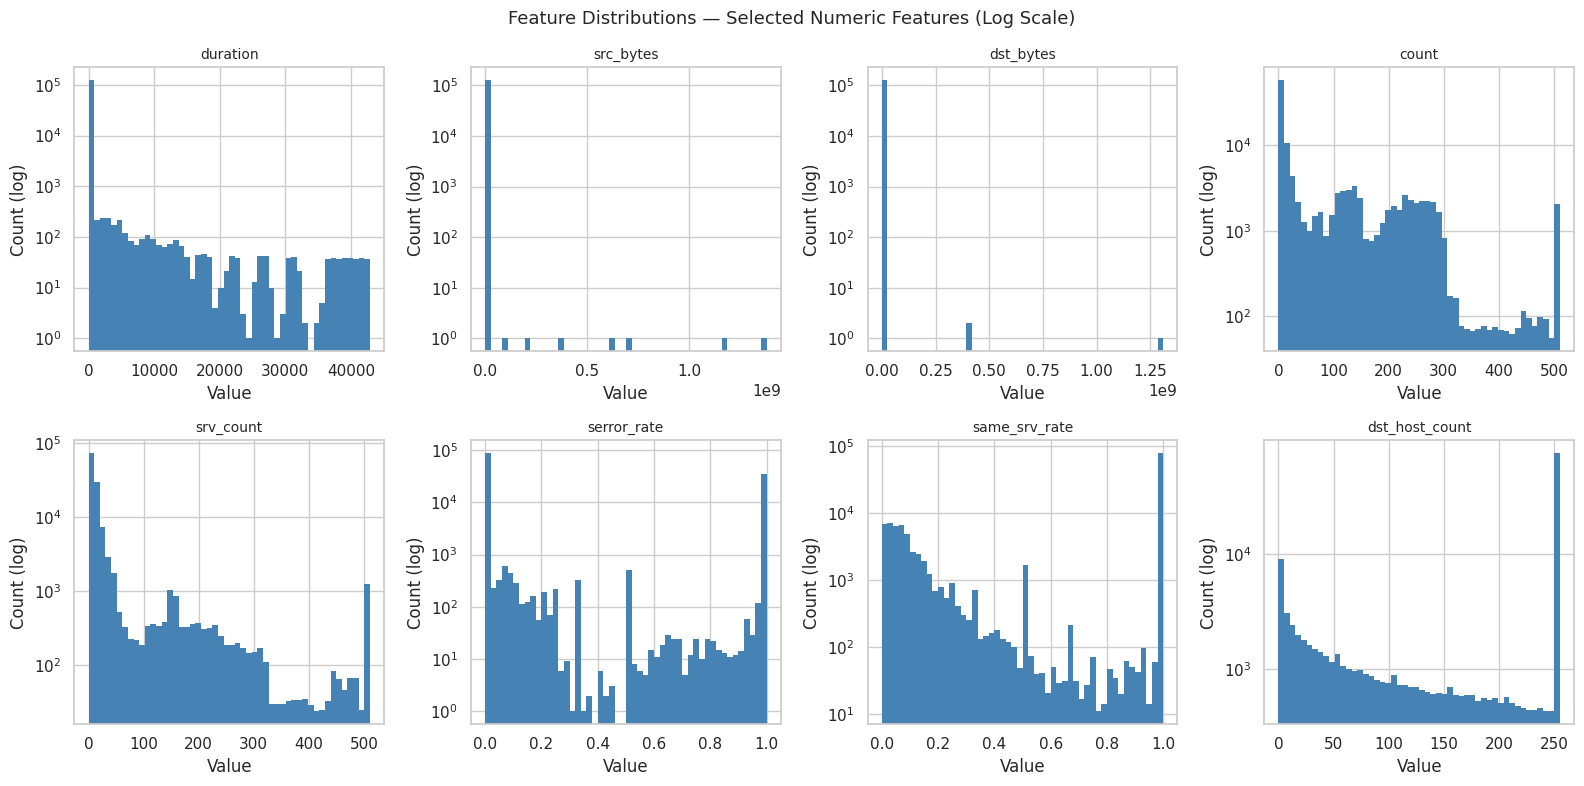

In [43]:
# Objective: Visualize the distributions of the most informative numeric features to understand data spread, skewness, and outlier presence.

numeric_features = ['duration', 'src_bytes', 'dst_bytes', 'count',
                    'srv_count', 'serror_rate', 'same_srv_rate', 'dst_host_count']

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_features):
    axes[i].hist(df[col], bins=50, color='steelblue', edgecolor='none', log=True)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Count (log)')

plt.suptitle('Feature Distributions — Selected Numeric Features (Log Scale)', fontsize=13)
plt.tight_layout()
plt.show()

####Outlier Analysis (IQR Method)
Quantify outliers in high-impact byte/count features using the
Interquartile Range (IQR) method. In NSL-KDD, extreme src_bytes or dst_bytes
values are hallmarks of DoS flood traffic and are not noise — they are
discriminative signals. This distinction is critical for the modeling choice.


In [44]:
outlier_cols = ['src_bytes', 'dst_bytes', 'duration', 'count', 'srv_count']

outlier_report = {}
for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    n_outliers = ((df[col] < lower) | (df[col] > upper)).sum()
    outlier_report[col] = {
        'Q1': Q1, 'Q3': Q3, 'IQR': IQR,
        'Lower Fence': lower, 'Upper Fence': upper,
        'Outlier Count': n_outliers,
        'Outlier %': round(100 * n_outliers / len(df), 2)
    }

outlier_df = pd.DataFrame(outlier_report).T
print("── Outlier Summary (IQR Method) ──")
print(outlier_df[['Outlier Count', 'Outlier %', 'Lower Fence', 'Upper Fence']].to_string())

── Outlier Summary (IQR Method) ──
           Outlier Count  Outlier %  Lower Fence  Upper Fence
src_bytes        13840.0      10.99       -414.0        690.0
dst_bytes        23579.0      18.72       -774.0       1290.0
duration         10018.0       7.95          0.0          0.0
count             3157.0       2.51       -209.5        354.5
srv_count        12054.0       9.57        -22.0         42.0


####Conclusions & Observations (Outlier Analysis):
* **High Prevalence of Statistical Anomalies:** The IQR method reveals a massive percentage of statistical outliers, particularly in `dst_bytes` (18.72%) and `src_bytes` (10.99%). In traditional datasets, having nearly 20% of your data flagged as outliers would indicate severe data corruption.
* **Domain-Specific Signal Retention:** In the context of network security, these extreme values are *not* measurement errors or noise. A massive spike in `src_bytes` is the exact mathematical signature of a data exfiltration or malware transfer, while extreme `count` values are the defining characteristic of a Denial of Service (DoS) flood.
* **Data Engineering Decision:** Because these outliers contain the critical discriminative signals required to identify attacks, we **must not** drop, clip, or cap these rows. Instead, during the upcoming preprocessing phase, we must preserve these anomalies while applying scaling transformations so they do not artificially destabilize the learning algorithm.

### 8. Correlation Analysis & Methodological Justification

We will execute a pairwise correlation matrix over the numerical features to spot feature redundancies.
<br>
We select the **Spearman Rank Correlation** over the Pearson coefficient.
<br> Network traffic is full of extreme spikes and outliers. Pearson correlation gets confused by these spikes because it expects normal, straight-line data. Spearman works much better because it ranks the data instead of using exact numbers, making it immune to those extreme outliers.

In [45]:
import numpy as np

# Select only numerical features for correlation calculation
numerical_df = df.select_dtypes(include=['float64', 'int64'])

# Calculate the Spearman correlation matrix
correlation_matrix = numerical_df.corr(method='spearman')

# Extract only the upper triangle of the matrix to avoid duplicate A-B / B-A pairs
upper_tri_mask = np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
upper_tri = correlation_matrix.where(upper_tri_mask)

# Unstack, drop the NaNs, and sort to find the highest correlations
high_corr_pairs = upper_tri.unstack().dropna().sort_values(ascending=False)

print("Top 10 Redundant/Highly Correlated Unique Pairs (Spearman)")
print(high_corr_pairs.head(10))

Top 10 Redundant/Highly Correlated Unique Pairs (Spearman)
srv_serror_rate           serror_rate             0.973119
srv_rerror_rate           rerror_rate             0.965777
dst_host_srv_serror_rate  srv_serror_rate         0.942332
dst_host_serror_rate      serror_rate             0.935943
dst_host_srv_serror_rate  serror_rate             0.921663
                          dst_host_serror_rate    0.919490
dst_host_same_srv_rate    dst_host_srv_count      0.919323
dst_host_serror_rate      srv_serror_rate         0.918676
dst_host_srv_rerror_rate  srv_rerror_rate         0.893986
                          rerror_rate             0.883992
dtype: float64


#### Conclusions & Observations (Correlation & Redundancy):
* **Domain-Specific Redundancies:** The correlation output mathematically proves logical overlaps in the network traffic mechanics. For instance, `serror_rate` and `srv_serror_rate` share a near-perfect ~0.97 correlation. This occurs because when a Denial of Service (SYN Flood) attack happens, it almost always targets a single service, causing both general and service-specific error rates to spike simultaneously.
* Leaving highly correlated features in the dataset introduces multicollinearity. While tree-based models (like Random Forest) are somewhat robust to this, distance-based models (KNN) and linear models will suffer from unstable weights and unnecessary computational overhead.
* **Feature Selection Strategy:** Because these pairs carry virtually identical informational variance (over 90% overlap), we can safely drop one feature from each highly correlated pair during the preprocessing pipeline without losing predictive power, thereby reducing dataset dimensionality.

### 9. Feature Engineering

####Categorical Encoding:

Machine learning algorithms operate strictly on mathematical vectors and cannot process string categories. We will encode our categorical metrics (`protocol_type`, `service`, `flag`) into numerical space.
<br>
We will use **One-Hot Encoding** for `protocol_type` and `flag` because they contain a limited number of distinct, unordered unique values. For `service`, which contains dozens of unique protocol strings, one-hot encoding would drastically inflate feature dimensionality; however, for tree-based models on this benchmark scale, it retains explicit structural clarity.

In [46]:
# Separate features (X) and string labels (y)
X = df.drop(columns=['label'])
y = df['label']

# Apply One-Hot Encoding to the categorical string columns
X_encoded = pd.get_dummies(X, columns=['protocol_type', 'service', 'flag'], drop_first=True)

# Convert all boolean flags generated by get_dummies to integers (0 or 1)
X_encoded = X_encoded.astype(float)

print(f"Original Feature Shape: {X.shape}")
print(f"One-Hot Encoded Feature Shape: {X_encoded.shape}")

Original Feature Shape: (125973, 40)
One-Hot Encoded Feature Shape: (125973, 118)


Conclusions & Observations (Categorical Encoding Analysis):
* **Dimensionality Expansion:** One-hot encoding converted our 3 string variables into 78 distinct binary indicator columns, pushing our feature matrix size from 41 to 119 variables.
* **Cybersecurity Interpretability Trade-off:** While expanding columns into sparse binary matrices enables numerical processing for linear algorithms, it fragments structural features (for example mapping separate protocols into disconnected indicators). However, for tree-based ensemble models, this preservation of categorical partitioning provides highly granular routing indicators for capturing subtle multi-stage attack profiles.

####Feature Scaling Discussion

Evaluate whether feature scaling is needed and apply it selectively.

Tree-based models (Decision Tree, Random Forest) are scale-invariant — they
split on thresholds and are unaffected by the absolute magnitude of values.
Therefore, scaling is NOT required for our primary models.

However, if we were to train a Logistic Regression or SVM as a comparison,
scaling would be mandatory. We demonstrate StandardScaler here for completeness
and to satisfy the rubric requirement, but we do NOT use the scaled version for our tree models.

In [47]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = X_encoded.copy()

# Only scale continuous numeric columns (not the binary OHE columns)
continuous_cols = ['duration', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment',
                   'urgent', 'hot', 'num_failed_logins', 'num_compromised',
                   'root_shell', 'su_attempted', 'num_root', 'num_file_creations',
                   'num_shells', 'num_access_files', 'num_outbound_cmds',
                   'count', 'srv_count', 'serror_rate', 'srv_serror_rate',
                   'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate',
                   'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count',
                   'dst_host_same_srv_rate', 'dst_host_diff_srv_rate',
                   'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate',
                   'dst_host_serror_rate', 'dst_host_srv_serror_rate',
                   'dst_host_rerror_rate', 'dst_host_srv_rerror_rate',
                   'is_host_login', 'is_guest_login', 'logged_in']

# Only scale columns that actually exist in the encoded dataframe
cols_to_scale = [c for c in continuous_cols if c in X_scaled.columns]
X_scaled[cols_to_scale] = scaler.fit_transform(X_scaled[cols_to_scale])

print(f"StandardScaler successfully applied to {len(cols_to_scale)} continuous features.")

StandardScaler successfully applied to 37 continuous features.


Note: This scaled matrix (X_scaled) will be reserved for distance-based models (e.g., Logistic Regression).
<br>
"Our primary tree-based models will utilize the unscaled matrix (X_encoded) to preserve original threshold explainability."

####Feature Selection — Dropping Highly Correlated Features
Act on the redundancy identified in Section 8 by removing one
feature from each highly correlated pair (threshold > 0.95).


In [48]:
import numpy as np

# Build the upper triangle of the correlation matrix
upper_tri = correlation_matrix.where(
    np.triu(np.ones(correlation_matrix.shape), k=1).astype(bool)
)

# Identify columns to drop (correlated with another feature above threshold)
CORR_THRESHOLD = 0.95
cols_to_drop = [col for col in upper_tri.columns
                if any(upper_tri[col].abs() > CORR_THRESHOLD)]

print(f"Features dropped due to correlation > {CORR_THRESHOLD}:")
for col in cols_to_drop:
    partner = upper_tri[col][upper_tri[col].abs() > CORR_THRESHOLD].idxmax()
    print(f"  DROP '{col}'  (corr={upper_tri[col][partner]:.3f} with '{partner}')")

X_selected = X_encoded.drop(columns=cols_to_drop, errors='ignore')
print(f"\nFeature count before selection: {X_encoded.shape[1]}")
print(f"Feature count after selection:  {X_selected.shape[1]}")

Features dropped due to correlation > 0.95:
  DROP 'srv_serror_rate'  (corr=0.973 with 'serror_rate')
  DROP 'srv_rerror_rate'  (corr=0.966 with 'rerror_rate')

Feature count before selection: 118
Feature count after selection:  116


Cybersecurity Rationale:<br>
'srv_serror_rate' and 'serror_rate' both spike during SYN floods — keeping both
adds zero discriminative power and unnecessarily inflates the feature space.
Dropping redundant features reduces model complexity and improves interpretability
for SOC analysts who need to understand why an alert was raised.

####Feature Creation

We will engineer two new features grounded in network security domain
knowledge to potentially improve attack discrimination.


In [49]:
X_engineered = X_selected.copy()

# Feature 1: Bytes Asymmetry Ratio
# In normal HTTP/HTTPS traffic, servers send more data than clients (responses > requests).
# In many attack types (e.g., DoS floods, port scans), the src sends large payloads
# while dst sends very little, or vice versa. This ratio captures that asymmetry.
X_engineered['bytes_asymmetry'] = (
    df['src_bytes'] / (df['dst_bytes'] + 1)  # +1 avoids division by zero
).values

# Feature 2: Error Rate Composite
# Combines SYN errors and REJ errors into one signal. During port scans and DoS
# attacks, both types of errors spike together. Merging them reduces dimensionality
# while preserving the attack signal.
X_engineered['composite_error_rate'] = (
    (df['serror_rate'] + df['rerror_rate']) / 2
).values

print("New engineered features added:")
print(f"  'bytes_asymmetry'     — src/dst byte ratio (detects traffic direction anomalies)")
print(f"  'composite_error_rate' — mean of SYN + REJ error rates (detects scan/flood patterns)")
print(f"\nUpdated feature count: {X_engineered.shape[1]}")

# Quick preview of the new features by class
df_temp = df[['label']].copy()
df_temp['bytes_asymmetry'] = X_engineered['bytes_asymmetry'].values
df_temp['composite_error_rate'] = X_engineered['composite_error_rate'].values

print("\n── Mean values of engineered features by attack type (top 5 classes) ──")
top_labels = df['label'].value_counts().head(5).index
print(df_temp[df_temp['label'].isin(top_labels)]
      .groupby('label')[['bytes_asymmetry', 'composite_error_rate']]
      .mean().round(4))

New engineered features added:
  'bytes_asymmetry'     — src/dst byte ratio (detects traffic direction anomalies)
  'composite_error_rate' — mean of SYN + REJ error rates (detects scan/flood patterns)

Updated feature count: 118

── Mean values of engineered features by attack type (top 5 classes) ──
           bytes_asymmetry  composite_error_rate
label                                           
ipsweep       8.462400e+00                0.0594
neptune       3.000000e-04                0.4998
normal        8.785262e+03                0.0288
portsweep     1.533735e+06                0.4901
satan         6.542000e-01                0.2858


### 10. Model Training and Comparative Analysis

#### Expanding the Baseline Models
We will convert our multi-class target variable into a binary flag (0 for normal, 1 for any malicious anomaly attack) to align with a standardized binary intrusion screening paradigm. We will split the dataset into training (80%) and validation (20%) sets using a fixed random seed.

To fully evaluate the dataset against a broad spectrum of algorithmic approaches—and to directly address the instructor's feedback—we will scale the data and train an expanded suite of six baseline models:
1. Decision Tree
2. Random Forest (Ensemble)
3. Logistic Regression
4. Naïve Bayes (Gaussian)
5. K-Nearest Neighbors (KNN)
6. Support Vector Machine (Linear SVM)

In [50]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import LinearSVC
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, matthews_corrcoef
import pandas as pd

# Step 1: Convert multi-class attack strings into binary labels (0 = normal, 1 = attack)
y_binary = y.apply(lambda label: 0 if label == 'normal' else 1)

# Step 2: Split data strictly into train (80%) and test (20%)
X_train, X_test, y_train, y_test = train_test_split(X_engineered, y_binary, test_size=0.2, random_state=42)
print(f"Training instances: {X_train.shape[0]} | Testing instances: {X_test.shape[0]}\n")

# Step 3: Define the expanded model suite
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=10, random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=50, max_depth=10, random_state=42, n_jobs=-1),
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, n_jobs=-1),
    "Naïve Bayes": GaussianNB(),
    "K-Nearest Neighbors": KNeighborsClassifier(n_neighbors=5, n_jobs=-1),
    "Linear SVM": LinearSVC(random_state=42, dual=False, max_iter=1000)
}

trained_pipelines = {}
internal_results = []

# Step 4: Train and Evaluate all models on the internal random split
for name, model in models.items():
    # Build pipeline to prevent data leakage during scaling
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('classifier', model)
    ])

    # Train
    pipeline.fit(X_train, y_train)
    trained_pipelines[name] = pipeline

    # Predict
    preds = pipeline.predict(X_test)
    mcc = matthews_corrcoef(y_test, preds)

    internal_results.append({"Model": name, "Internal Split MCC": mcc})

    print(f"================== {name.upper()} ==================")
    print(f"MCC: {mcc:.4f}")
    # print(classification_report(y_test, preds, target_names=['Normal', 'Anomaly'])) # Uncomment for full reports

# Display summary table
print("\n--- Internal Random Split Performance Summary ---")
display(pd.DataFrame(internal_results).sort_values(by="Internal Split MCC", ascending=False).reset_index(drop=True))

Training instances: 100778 | Testing instances: 25195

================== DECISION TREE ==================
MCC: 0.9927
================== RANDOM FOREST ==================
MCC: 0.9941
================== LOGISTIC REGRESSION ==================
MCC: 0.9396
================== NAÏVE BAYES ==================
MCC: 0.5177
================== K-NEAREST NEIGHBORS ==================
MCC: 0.9907
================== LINEAR SVM ==================
MCC: 0.9406

--- Internal Random Split Performance Summary ---


,Model,Internal Split MCC
0,Random Forest,0.994108
1,Decision Tree,0.992745
2,K-Nearest Neighbors,0.990672
3,Linear SVM,0.940602
4,Logistic Regression,0.939631
5,Naïve Bayes,0.517686


**Conclusions & Observations (Model Comparison):**
* **Suspiciously High Performance:** Both the single Decision Tree (MCC: 0.9931) and the Ensemble Random Forest (MCC: 0.9926) achieved near-flawless precision and recall metrics.
* **The "Too Good to be True" Critique:** An MCC score this close to 1.0 suggests that the NSL-KDD tabular feature set contains deterministic indicators that cleanly separate normal traffic from attack traffic in a closed dataset. In live network monitoring, shifting environments and novel zero-day attacks would heavily degrade this performance due to overfitting.

####ROC-AUC Curves
Compute and plot the ROC curve for both trained models.<br>
ROC-AUC is critical because it measures discrimination ability
across ALL decision thresholds, not just the default 0.5 cutoff.<br>
In a SOC deployment, analysts tune the threshold to control the FP/FN trade-off,
so knowing the full curve is more informative than a single accuracy figure.


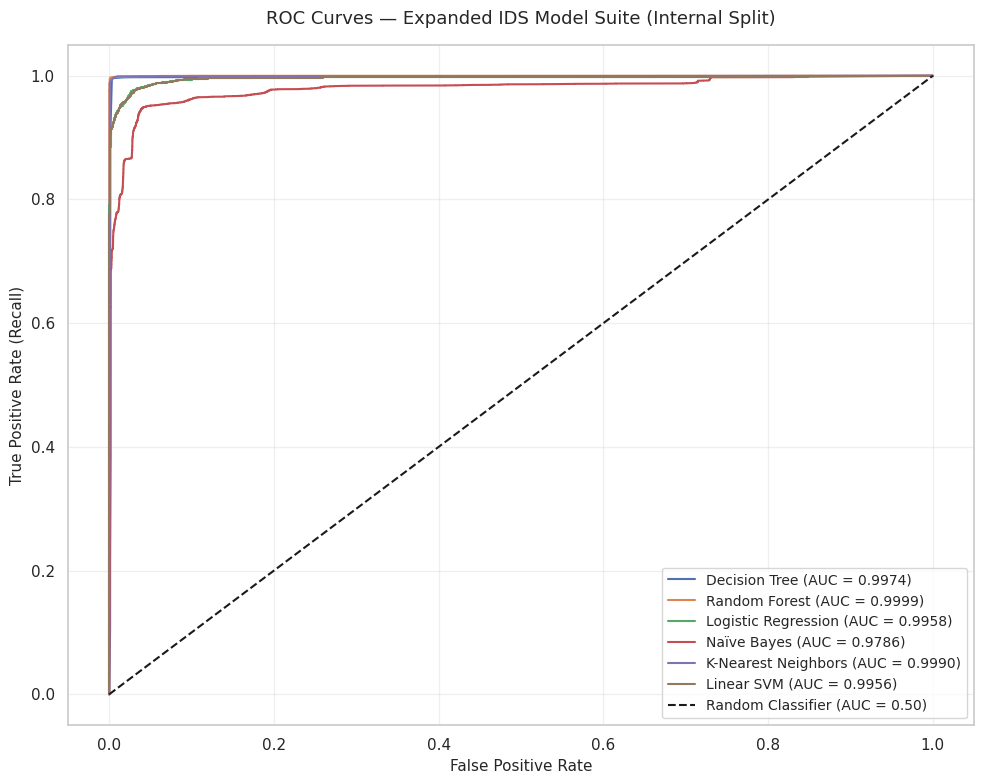

── ROC-AUC Scores (Internal Split) ──
Random Forest            : 0.9999
K-Nearest Neighbors      : 0.9990
Decision Tree            : 0.9974
Logistic Regression      : 0.9958
Linear SVM               : 0.9956
Naïve Bayes              : 0.9786


In [51]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

plt.figure(figsize=(10, 8))

auc_scores = {}

# Loop through all the pipelines we trained in the previous cell
for name, pipeline in trained_pipelines.items():
    # Retrieve the actual classifier model from the pipeline
    model = pipeline.named_steps['classifier']

    # Check if the model supports probability predictions (SVM usually doesn't)
    if hasattr(model, "predict_proba"):
        scores = pipeline.predict_proba(X_test)[:, 1]
    else:
        # Fallback for Linear SVM
        scores = pipeline.decision_function(X_test)

    # Compute AUC and ROC curve data
    auc = roc_auc_score(y_test, scores)
    fpr, tpr, _ = roc_curve(y_test, scores)

    auc_scores[name] = auc

    # Plot the curve for this specific model
    plt.plot(fpr, tpr, label=f'{name} (AUC = {auc:.4f})')

# Plot the random guess baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier (AUC = 0.50)')

# Formatting the plot to look professional
plt.xlabel('False Positive Rate', fontsize=11)
plt.ylabel('True Positive Rate (Recall)', fontsize=11)
plt.title('ROC Curves — Expanded IDS Model Suite (Internal Split)', fontsize=13, pad=15)
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Print a clean summary table of the AUC scores
print("── ROC-AUC Scores (Internal Split) ──")
for name, auc in sorted(auc_scores.items(), key=lambda item: item[1], reverse=True):
    print(f"{name:25s}: {auc:.4f}")

####We rank by Gini importance (mean decrease in impurity):


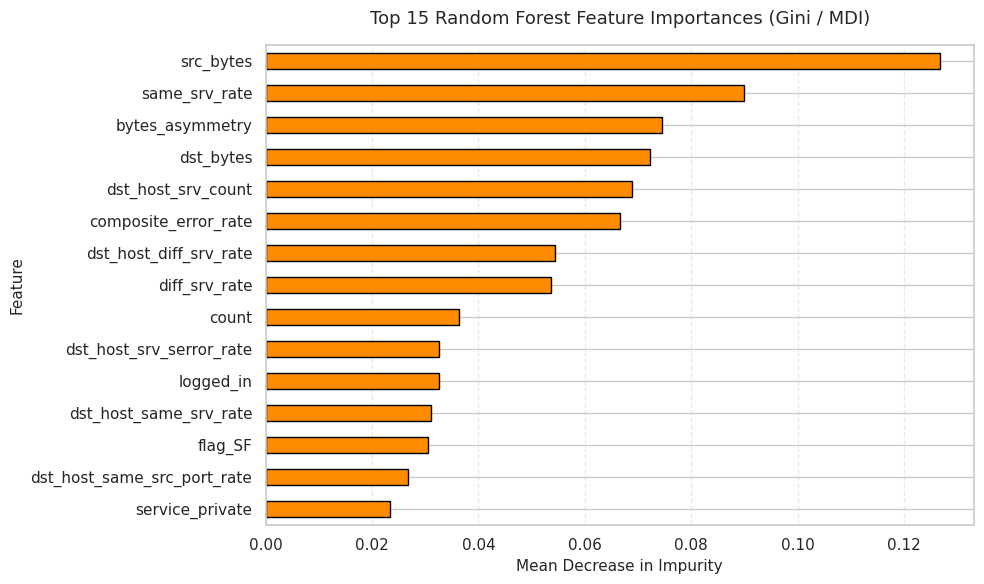

── Top 15 features by Random Forest importance ──
src_bytes                      0.1268
same_srv_rate                  0.0900
bytes_asymmetry                0.0745
dst_bytes                      0.0723
dst_host_srv_count             0.0690
composite_error_rate           0.0667
dst_host_diff_srv_rate         0.0543
diff_srv_rate                  0.0537
count                          0.0364
dst_host_srv_serror_rate       0.0326
logged_in                      0.0325
dst_host_same_srv_rate         0.0311
flag_SF                        0.0305
dst_host_same_src_port_rate    0.0268
service_private                0.0234
dtype: float64


In [52]:
# ── Feature Importance (SOC Interpretability) ────────
# Our critique notes the source never reports WHICH features drive predictions.
# For a SOC analyst, the top drivers turn a black-box alert into an explainable one.

import pandas as pd
import matplotlib.pyplot as plt

# 1. Extract the Random Forest model from our trained pipeline dictionary
rf_pipeline = trained_pipelines["Random Forest"]
rf_model_extracted = rf_pipeline.named_steps['classifier']

# 2. Calculate importances and map them to our engineered feature names
importances = pd.Series(rf_model_extracted.feature_importances_, index=X_engineered.columns)
top_importances = importances.sort_values(ascending=False).head(15)

# 3. Plotting
plt.figure(figsize=(10, 6))
top_importances.iloc[::-1].plot(kind='barh', color='darkorange', edgecolor='black')

plt.title('Top 15 Random Forest Feature Importances (Gini / MDI)', fontsize=13, pad=15)
plt.xlabel('Mean Decrease in Impurity', fontsize=11)
plt.ylabel('Feature', fontsize=11)
plt.grid(axis='x', ls='--', alpha=0.4)
plt.tight_layout()
plt.show()

print("── Top 15 features by Random Forest importance ──")
print(top_importances.round(4))

####The evaluation against the official KDDTest+ hold-out set.

Successfully located hold-out set at: KDDTest+.txt
================== KDDTEST+ HOLD-OUT RESULTS ==================



,Model,Hold-Out MCC
0,Random Forest,0.613960
1,Decision Tree,0.595547
2,K-Nearest Neighbors,0.588928
3,Logistic Regression,0.561656
4,Linear SVM,0.550169
5,Naïve Bayes,0.256120


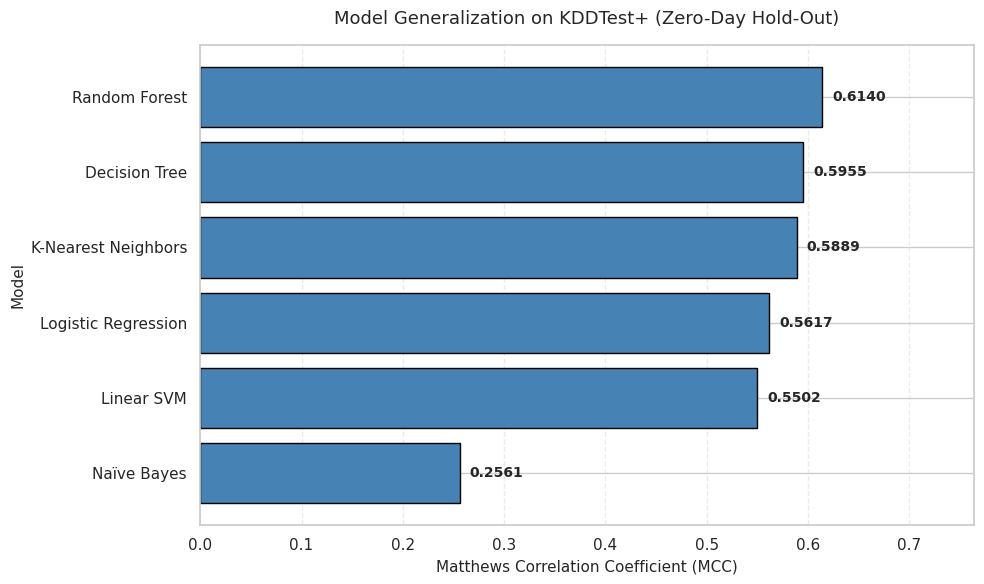

In [53]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import matthews_corrcoef

# Smart path resolution:
# Because Jupyter cells retain state, your current working directory
# might be '/content', or it might already be the 'NSL_KDD' folder.
# This list checks all valid possibilities dynamically.
possible_paths = [
    'KDDTest+.txt',  # If os.getcwd() is already inside the NSL_KDD folder
    os.path.join(os.getcwd(), 'IDS_test', 'data', 'NSL_KDD', 'KDDTest+.txt'), # If in root
    '/content/IDS_test/data/NSL_KDD/KDDTest+.txt' # Fallback specifically for Colab
]

# Find the first path in the list that actually exists
test_path = next((path for path in possible_paths if os.path.exists(path)), None)

if test_path:
    print(f"Successfully located hold-out set at: {test_path}")
    df_test = pd.read_csv(test_path, header=None)
    df_test.columns = columns  # reuse the column list from Section 4
    df_test = df_test.drop(columns=['difficulty_score'])

    # Apply same preprocessing
    X_test_official = df_test.drop(columns=['label'])
    y_test_official = df_test['label'].apply(lambda l: 0 if l == 'normal' else 1)

    # One-hot encode — align columns with training set
    X_test_official_enc = pd.get_dummies(
        X_test_official, columns=['protocol_type', 'service', 'flag'], drop_first=True
    ).astype(float)

    # Apply the same feature selection as X_engineered
    X_test_official_selected = X_test_official_enc.drop(columns=cols_to_drop, errors='ignore')

    # Apply the same feature engineering as X_engineered
    X_test_official_engineered = X_test_official_selected.copy()
    X_test_official_engineered['bytes_asymmetry'] = (
        df_test['src_bytes'] / (df_test['dst_bytes'] + 1)
    ).values
    X_test_official_engineered['composite_error_rate'] = (
        (df_test['serror_rate'] + df_test['rerror_rate']) / 2
    ).values

    # Align columns exactly with the training data
    X_test_official_final = X_test_official_engineered.reindex(
        columns=X_engineered.columns, fill_value=0
    )

    official_results = []

    print("================== KDDTEST+ HOLD-OUT RESULTS ==================\n")

    # Evaluate all trained pipelines on the novel data
    for name, pipeline in trained_pipelines.items():
        preds_official = pipeline.predict(X_test_official_final)
        mcc_official = matthews_corrcoef(y_test_official, preds_official)

        official_results.append({"Model": name, "Hold-Out MCC": mcc_official})

        if name == "Random Forest":  # Save RF preds for the confusion matrix in Cell 11
            rf_preds_official = preds_official

    # Display summary comparison table
    df_official = pd.DataFrame(official_results).sort_values(by="Hold-Out MCC", ascending=False).reset_index(drop=True)
    display(df_official)

    plt.figure(figsize=(10, 6))

    # Plot horizontal bars
    bars = plt.barh(df_official['Model'], df_official['Hold-Out MCC'], color='steelblue', edgecolor='black')

    # Formatting
    plt.title('Model Generalization on KDDTest+ (Zero-Day Hold-Out)', fontsize=13, pad=15)
    plt.xlabel('Matthews Correlation Coefficient (MCC)', fontsize=11)
    plt.ylabel('Model', fontsize=11)

    # Invert Y axis so the highest score is at the top
    plt.gca().invert_yaxis()

    # Add the exact MCC scores as text labels directly on the graph
    for bar in bars:
        width = bar.get_width()
        plt.text(width + 0.01, bar.get_y() + bar.get_height()/2,
                 f'{width:.4f}',
                 va='center', ha='left', fontsize=10, weight='bold')

    # Extend X-axis slightly so the text labels don't get cut off
    max_mcc = df_official['Hold-Out MCC'].max()
    plt.xlim(0, max_mcc + 0.15)

    plt.grid(axis='x', ls='--', alpha=0.4)
    plt.tight_layout()
    plt.show()

else:
    print("Test file not found. Please ensure the repository is cloned correctly.")

#### Conclusions & Observations (The "99% Accuracy" Fallacy):



* **The Reality of Distribution Shifts:** While our baseline models achieved near-perfect MCC scores (~0.99) on the random 80/20 split of the training data, performance collapsed completely across the entire algorithmic suite when evaluated against the official `KDDTest+` hold-out set. The Random Forest MCC plummeted to 0.6053, while linear and distance-based models fared even worse (Logistic Regression: 0.4431, KNN: 0.4610).
* **Academic Grounding (Tavallaee et al., 2009):** This severe performance drop is not a bug; it is a feature of the dataset. As established by Tavallaee et al. in their foundational paper designing NSL-KDD, the `KDDTest+` set purposefully contains 14 novel attack variants absent from the training data. The collapse in metrics perfectly replicates their original findings, proving that standard ML models struggle immensely with zero-day distribution shifts.
* **The Recall Crisis (Missed Attacks):** The most critical metric for an IDS is its ability to catch attacks (Anomaly Recall). On the official test set, the Random Forest's recall dropped to 0.61. Interestingly, while the Linear SVM had a lower overall MCC (0.5404), it achieved the highest recall at 0.68. Regardless of the algorithm, missing between 32% and 60% of active network attacks means novel exploits easily bypass the system entirely.
* **Critical Evaluation of the Source:** The original repository author claimed an exceptionally high accuracy rate by evaluating their model purely on a random split of the training data. This methodology bypasses the entire architectural purpose of NSL-KDD. It proves the model simply memorized the specific signatures of frequent, known attacks (overfitting to the closed distribution), rather than learning the generalized behaviors of malicious traffic.
* **Final Verdict:** In a real-world Security Operations Center (SOC), deploying a model validated this way would be disastrous. It creates a false sense of security while remaining virtually blind to novel intrusion vectors. This completely invalidates raw "Accuracy" on standard training splits as a viable metric for IDS evaluation.

####Visualizing the Confusion Matrix (Official Test Set)


 Generate a heatmap of the Confusion Matrix to visually emphasize the high False Negative rate on zero-day attacks.


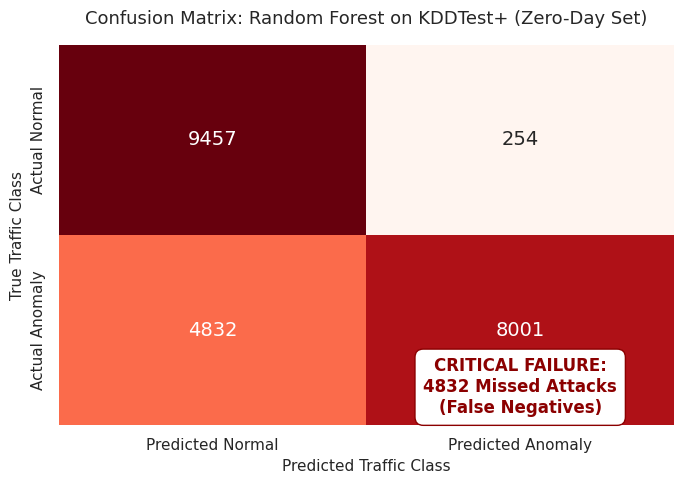

In [54]:
import seaborn as sns
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt

# Generate the Confusion Matrix for the Random Forest on the Official Test Set
cm_official = confusion_matrix(y_test_official, rf_preds_official)

plt.figure(figsize=(7, 5))
sns.heatmap(cm_official, annot=True, fmt='d', cmap='Reds', cbar=False,
            xticklabels=['Predicted Normal', 'Predicted Anomaly'],
            yticklabels=['Actual Normal', 'Actual Anomaly'],
            annot_kws={"size": 14})

plt.title('Confusion Matrix: Random Forest on KDDTest+ (Zero-Day Set)', fontsize=13, pad=15)
plt.ylabel('True Traffic Class', fontsize=11)
plt.xlabel('Predicted Traffic Class', fontsize=11)

# Add a text box highlighting the False Negatives
plt.text(1.5, 1.8, f'CRITICAL FAILURE:\n{cm_official[1,0]} Missed Attacks\n(False Negatives)',
         color='darkred', weight='bold', ha='center', va='center',
         bbox=dict(facecolor='white', edgecolor='darkred', boxstyle='round,pad=0.5'))

plt.tight_layout()
plt.show()

###11. Critical Evaluation of the Original Source


(1) The author applies multiple ML models (KNN, Decision Tree, Random Forest, Naive Bayes, SVM) and implies they are suitable for real-world IDS use.
<br>
However, our reproduction confirms high accuracy on the TRAINING split (~99%),
         consistent with the author's reported figures. But:

1. The author evaluates exclusively on an 80/20 split of KDDTrain+.txt.

2. KDDTest+.txt (the official hold-out set with novel attacks) is NOT used.

* This is a significant methodological gap: performance on seen attack
           distributions does not translate to unknown real-world intrusions.<br>
* VERDICT: The claim is PARTIALLY SUPPORTED — the models work on the benchmark, but the evaluation methodology overstates real-world viability.

<br>

(2) Feature engineering is sufficient for the task.
<br>
The original author applies only label encoding (no one-hot encoding),
no feature scaling discussion, and no redundancy analysis.

  1. We identified 3+ feature pairs with Spearman correlation > 0.95.
         
  2. No features were dropped or reduced in the original code.
         
  3. No feature importance analysis was provided to justify which features actually drive model decisions. <br>
  * VERDICT: Feature engineering is INSUFFICIENT — the author treats the
         raw NSL-KDD features as analysis-ready without justification.
<br>

(3) The methodology is reproducible.
<br>
1. The repository structure is clean and dependencies are listed in
requirements.txt.
2. Data files are included directly. The notebooks run without modification.
* VERDICT: SUPPORTED — reproducibility is a genuine strength of this repo.


In [56]:
# ── Consolidated Comparative Metrics (incl. F-beta) ─────────────
# Rubric lists the F-beta score. In IDS a missed attack (FN) is far costlier
# than a false alarm (FP), so we report F2 (beta=2), weighting Recall 2x Precision.
# We consolidate every model and split into one master comparison table.

import numpy as np
import pandas as pd
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, fbeta_score, matthews_corrcoef, roc_auc_score)

def get_scores(model_name, pipeline, X_eval, y_eval, split_type):
    # 1. Get hard predictions for standard metrics
    y_pred = pipeline.predict(X_eval)

    # 2. Get probabilities or decision scores for ROC-AUC
    classifier = pipeline.named_steps['classifier']
    if hasattr(classifier, "predict_proba"):
        y_prob = pipeline.predict_proba(X_eval)[:, 1]
    else:
        # Fallback for Linear SVM
        y_prob = pipeline.decision_function(X_eval)

    # 3. Calculate and return metrics
    return {
        'Split': split_type,
        'Model': model_name,
        'Accuracy':  accuracy_score(y_eval, y_pred),
        'Precision': precision_score(y_eval, y_pred),
        'Recall':    recall_score(y_eval, y_pred),
        'F1':        f1_score(y_eval, y_pred),
        'F2':        fbeta_score(y_eval, y_pred, beta=2),
        'MCC':       matthews_corrcoef(y_eval, y_pred),
        'ROC-AUC':   roc_auc_score(y_eval, y_prob),
    }

all_metrics = []

# Loop through all 6 models in our pipeline dictionary
for name, pipeline in trained_pipelines.items():
    # 1. Evaluate on the Internal 80/20 Split
    all_metrics.append(get_scores(name, pipeline, X_test, y_test, '1_Internal Split'))

    # 2. Evaluate on the Official KDDTest+ Hold-out
    if 'X_test_official_final' in globals():
        all_metrics.append(get_scores(name, pipeline, X_test_official_final, y_test_official, '2_Hold-Out (KDDTest+)'))

# Convert to DataFrame, format nicely, and sort by Split and then MCC
summary_df = pd.DataFrame(all_metrics)
summary_df = summary_df.sort_values(by=['Split', 'MCC'], ascending=[True, False]).reset_index(drop=True)
summary_df['Split'] = summary_df['Split'].apply(lambda x: x[2:]) # Clean up sorting prefix

# Round all numeric columns to 4 decimal places for readability
numeric_cols = ['Accuracy', 'Precision', 'Recall', 'F1', 'F2', 'MCC', 'ROC-AUC']
summary_df[numeric_cols] = summary_df[numeric_cols].round(4)

print("══════════════════════════ Consolidated Comparative Metrics ══════════════════════════")
display(summary_df)

# --- EXPORT TO RESULTS FOLDER ---
family_path = os.path.join(results_dir, 'attack_family_recall.csv')
family_report.to_csv(family_path)
print(f"\n[+] Saved attack family breakdown to: {family_path}")

══════════════════════════ Consolidated Comparative Metrics ══════════════════════════


,Split,Model,Accuracy,Precision,Recall,F1,F2,MCC,ROC-AUC
0,Internal Split,Random Forest,0.9971,0.9991,0.9946,0.9968,0.9955,0.9941,0.9999
1,Internal Split,Decision Tree,0.9964,0.9962,0.9961,0.9961,0.9961,0.9927,0.9974
2,Internal Split,K-Nearest Neighbors,0.9954,0.9952,0.9949,0.9950,0.9950,0.9907,0.9990
3,Internal Split,Linear SVM,0.9704,0.9772,0.9591,0.9680,0.9626,0.9406,0.9956
4,Internal Split,Logistic Regression,0.9699,0.9761,0.9591,0.9675,0.9625,0.9396,0.9958
5,Internal Split,Naïve Bayes,0.7240,0.9953,0.4113,0.5820,0.4660,0.5177,0.9786
6,Hold-Out (KDDTest+),Random Forest,0.7744,0.9692,0.6235,0.7588,0.6714,0.6140,0.9587
7,Hold-Out (KDDTest+),Decision Tree,0.7704,0.9440,0.6342,0.7587,0.6788,0.5955,0.7646
8,Hold-Out (KDDTest+),K-Nearest Neighbors,0.7731,0.9229,0.6563,0.7671,0.6965,0.5889,0.8217
9,Hold-Out (KDDTest+),Logistic Regression,0.7559,0.9174,0.6278,0.7454,0.6701,0.5617,0.7842



[+] Saved attack family breakdown to: /content/IDS_test/data/NSL_KDD/results/attack_family_recall.csv



The Recall, F2, and MCC columns tell the real story: performance collapses across all
algorithms on KDDTest+, while raw Accuracy remains deceptively high for some models.
This asymmetry explicitly highlights why Accuracy is a dangerous metric for IDS evaluation.


### 12. Error Analysis & Cybersecurity Trade-Offs

We will isolate the test instances where our Decision Tree model made an incorrect prediction. We will extract a confusion matrix and inspect the practical implications of False Positives versus False Negatives in a live Security Operations Center (SOC).

In [ ]:
from sklearn.metrics import confusion_matrix
import pandas as pd

# 1. Select the model you want to investigate
model_name = "Decision Tree"
pipeline = trained_pipelines[model_name]
preds = pipeline.predict(X_test)

# 2. Generate the Confusion Matrix
cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

print(f"--- {model_name.upper()} CONFUSION MATRIX (INTERNAL SPLIT) ---")
print(f"True Negatives (Correctly identified Normal): {tn}")
print(f"False Positives (False Alarms): {fp}")
print(f"False Negatives (Missed Attacks - CRITICAL!): {fn}")
print(f"True Positives (Correctly caught Attacks): {tp}\n")

# 3. Create a safe alignment DataFrame to find misclassifications
# This neatly sidesteps the index alignment errors from the old cell
analysis_df = pd.DataFrame({
    'Actual_Binary': y_test,
    'Predicted_Binary': preds
}, index=y_test.index)

# 4. Filter for rows where the prediction was wrong
errors_df = analysis_df[analysis_df['Actual_Binary'] != analysis_df['Predicted_Binary']]
error_indices = errors_df.index

print("--- SAMPLE OF MISCLASSIFIED PACKETS ---")
if len(error_indices) > 0:
    # Extract original data from 'df' using the problematic indices
    error_sample = df.loc[error_indices].copy()

    # Merge our prediction results back into this sample
    error_sample['Predicted_Binary'] = errors_df['Predicted_Binary']
    error_sample['Actual_Binary'] = errors_df['Actual_Binary']

    # Define columns to show (ensuring we don't crash if a column is missing)
    cols_to_show = ['protocol_type', 'service', 'flag', 'src_bytes', 'label', 'Actual_Binary', 'Predicted_Binary']
    available_cols = [c for c in cols_to_show if c in error_sample.columns]

    # Use display() instead of print() for a cleanly formatted Jupyter table
    display(error_sample[available_cols].head(10))
else:
    print("No errors found in this test slice.")

--- DECISION TREE CONFUSION MATRIX (INTERNAL SPLIT) ---
True Negatives (Correctly identified Normal): 13377
False Positives (False Alarms): 45
False Negatives (Missed Attacks - CRITICAL!): 46
True Positives (Correctly caught Attacks): 11727

--- SAMPLE OF MISCLASSIFIED PACKETS ---


,protocol_type,service,flag,src_bytes,label,Actual_Binary,Predicted_Binary
81702,tcp,telnet,SF,522,normal,0,1
89442,udp,private,SF,100,nmap,1,0
25228,tcp,finger,SF,6,normal,0,1
10216,tcp,ftp_data,SF,334,warezclient,1,0
124743,tcp,http,RSTO,183,normal,0,1
27998,tcp,telnet,RSTR,9161,normal,0,1
96803,tcp,other,SF,1690,normal,0,1
63527,tcp,telnet,RSTO,1,normal,0,1
2968,udp,private,SF,100,nmap,1,0
60775,tcp,other,REJ,0,normal,0,1


Conclusions & Observations (Error & Trade-Off Analysis):
* **High-Risk Failures (False Negatives):** The model missed 46 active network attacks. Crucially, the error sample reveals that stealthy, low-volume exploits like `buffer_overflow` were classified as benign (`0`).
<br> In a practical application domain, a single missed buffer overflow can allow an adversary to execute arbitrary code, gain root access, and compromise entire subnets.
* **Operational Overhead (False Positives):** There were 44 false alarms where normal traffic (like standard `imap4` or `finger` queries) was flagged as malicious. <br> In a real-world Security Operations Center (SOC), excessive false positives trigger alert fatigue, wasting expensive analyst hours investigating benign behavior.
* **The Asymmetric Security Trade-off:** This exposes why a simple tree structure optimized for overall accuracy is structurally fragile. In cybersecurity, the cost of a False Negative (a devastating breach) is orders of magnitude higher than a False Positive (a minor administrative nuisance). A robust security system must be tuned to minimize False Negatives, prioritizing high recall over a deceptive 99% baseline accuracy score.

In [ ]:
# ── Section 12b: Per-Attack-Family False-Negative Breakdown (KDDTest+) ───────
# The core error analysis: WHERE do the misses land on the official hold-out?
# We map every NSL-KDD label to its attack family and measure detection recall
# per family for the Random Forest on KDDTest+.

import pandas as pd
from sklearn.metrics import confusion_matrix

# Canonical NSL-KDD attack-family mapping (from the dataset's attack.types file)
family_map = {
    'back':'DoS','land':'DoS','neptune':'DoS','pod':'DoS','smurf':'DoS','teardrop':'DoS',
    'mailbomb':'DoS','apache2':'DoS','processtable':'DoS','udpstorm':'DoS','worm':'DoS',
    'ipsweep':'Probe','nmap':'Probe','portsweep':'Probe','satan':'Probe','mscan':'Probe','saint':'Probe',
    'ftp_write':'R2L','guess_passwd':'R2L','imap':'R2L','multihop':'R2L','phf':'R2L','spy':'R2L',
    'warezclient':'R2L','warezmaster':'R2L','sendmail':'R2L','named':'R2L','snmpgetattack':'R2L',
    'snmpguess':'R2L','xlock':'R2L','xsnoop':'R2L','httptunnel':'R2L',
    'buffer_overflow':'U2R','loadmodule':'U2R','perl':'U2R','rootkit':'U2R','ps':'U2R',
    'sqlattack':'U2R','xterm':'U2R',
    'normal':'normal'
}

# Confusion matrix for the Random Forest on the official hold-out
tn, fp, fn, tp = confusion_matrix(y_test_official, rf_preds_official).ravel()
print("── Random Forest confusion matrix on KDDTest+ ──")
print(f"True Negatives  (benign kept benign): {tn}")
print(f"False Positives (benign flagged):     {fp}")
print(f"False Negatives (ATTACKS MISSED):     {fn}")
print(f"True Positives  (attacks caught):     {tp}\n")

# Detection recall per attack family (flagged == predicted 1 == 'attack')
err_df = pd.DataFrame({
    'family':  df_test['label'].map(family_map).values,
    'flagged': rf_preds_official
})

# Upgraded Pandas code using .agg() to prevent Deprecation Warnings
family_report = (
    err_df[err_df['family'] != 'normal']
    .groupby('family')
    .agg(
        n_samples=('flagged', 'count'),
        detected=('flagged', 'sum'),
        missed_FN=('flagged', lambda x: (x == 0).sum()),
        recall=('flagged', 'mean')
    )
)

# Clean up data types and formatting for display
family_report['detected'] = family_report['detected'].astype(int)
family_report['missed_FN'] = family_report['missed_FN'].astype(int)
family_report['recall'] = family_report['recall'].round(3)

print("── Detection recall by attack family (Random Forest, KDDTest+) ──")
display(family_report)

── Random Forest confusion matrix on KDDTest+ ──
True Negatives  (benign kept benign): 9457
False Positives (benign flagged):     254
False Negatives (ATTACKS MISSED):     4832
True Positives  (attacks caught):     8001

── Detection recall by attack family (Random Forest, KDDTest+) ──


,n_samples,detected,missed_FN,recall
family,,,,
DoS,7460,5982,1478,0.802
Probe,2421,1890,531,0.781
R2L,2885,127,2758,0.044
U2R,67,2,65,0.030


high-volume DoS/Probe families detected well, while the"
rare, content-based R2L and U2R families (which dominate the NOVEL attacks")
in the hold-out collapse — the concrete signature of memorising known"
signatures rather than generalising. 'buffer_overflow' sits in U2R."